# Is Your Friend Actually Good at This?

**The scenario.** Your friend claims they correctly predicted 55% of football games
last season and made good money doing it. They have a pick for this weekend and want
you to follow it. Should you?

Binary thinking says: *"55% is above 50% — they know what they're doing, and I'll
probably win."* This exercise runs the numbers on both claims.

## What this notebook delivers

1. What 55% actually means for the single game you're about to bet on.
2. How often a pure coin flipper hits 55%+ over a 20-game season.
3. How sample size changes whether 55% is meaningful.
4. How many games your friend needs to have predicted for 55% to be convincing.
5. A takeaway on what went wrong with both assumptions.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

RNG = np.random.default_rng(42)

## 1. One game — taking his word for it

Assume your friend's 55% is completely real. Binary thinking says:
*"55% > 50% — I'll probably win."*
Simulate 1,000 people each following one pick at 55%. How many lose?

In [2]:
outcomes = RNG.binomial(1, 0.55, 1_000)
wins   = outcomes.sum()
losses = 1_000 - wins

print(f"Binary thinking: '55% > 50% — I'll probably win'")
print(f"Reality: {losses} out of 1,000 people lost following one pick at 55%")

Binary thinking: '55% > 50% — I'll probably win'
Reality: 455 out of 1,000 people lost following one pick at 55%


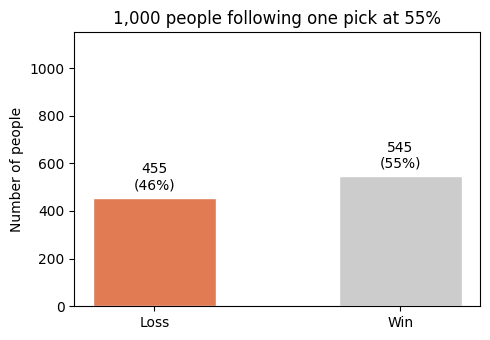

In [3]:
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(['Loss', 'Win'], [losses, wins],
              color=['#e07b54', '#cccccc'], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt=lambda v: f'{int(v):,}\n({v/1000:.0%})', padding=4, fontsize=10)
ax.set(title='1,000 people following one pick at 55%',
       ylabel='Number of people', ylim=(0, 1_150))
plt.tight_layout()
plt.show()

Even if your friend is genuinely right 55% of the time, you still lose on nearly
half the games you follow their advice for. A single pick is still a coin flip — just
a slightly weighted one.

## 2. The coin flipper problem — 20-game season

Now the harder question: is your friend actually skilled, or just lucky?
Simulate 1,000 people who pick games randomly (50/50) over a 20-game season.
How many hit 55% or better purely by chance?

In [4]:
random_correct = RNG.binomial(20, 0.50, 1_000)
hit_55_plus = (random_correct >= 11).sum()  # 55% of 20 = 11 correct

print(f"Out of 1,000 random guessers predicting 20 games:")
print(f"  {hit_55_plus} hit 55%+ by pure chance ({hit_55_plus/10:.1f}%)")
print(f"\nIf your friend predicted 20 games last season, their record could easily be luck.")

Out of 1,000 random guessers predicting 20 games:
  414 hit 55%+ by pure chance (41.4%)

If your friend predicted 20 games last season, their record could easily be luck.


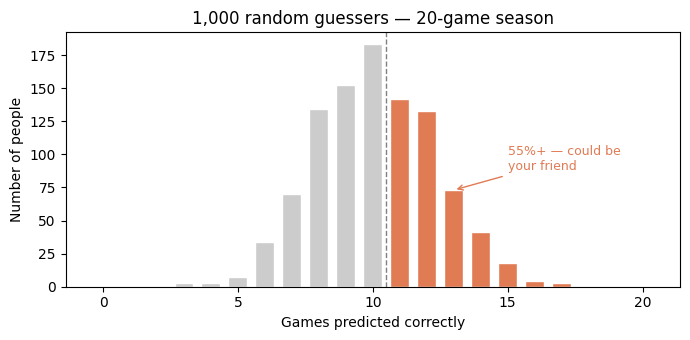

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
n, _, patches = ax.hist(random_correct, bins=range(0, 22), align='left',
                         rwidth=0.7, color='#cccccc', edgecolor='white')
for i, patch in enumerate(patches):
    if i >= 11:
        patch.set_facecolor('#e07b54')
ax.axvline(10.5, ls='--', color='gray', lw=1)
ax.set(title='1,000 random guessers — 20-game season',
       xlabel='Games predicted correctly', ylabel='Number of people')
ax.annotate('55%+ — could be\nyour friend',
            xy=(13, n[13]), xytext=(15, n[13] + 15),
            arrowprops=dict(arrowstyle='->', color='#e07b54'), color='#e07b54', fontsize=9)
plt.tight_layout()
plt.show()

A large chunk of pure coin flippers hit 55%+ over 20 games. Your friend's record
is not unusual at all — it lands squarely in the orange zone that chance alone produces.

## 3. Does the season length matter? — 100 games

Same simulation, but now each random guesser predicts 100 games.
How often does a coin flipper still hit 55%+?

In [6]:
random_correct_100 = RNG.binomial(100, 0.50, 1_000)
hit_55_100 = (random_correct_100 >= 55).sum()

print(f"Out of 1,000 random guessers predicting 100 games:")
print(f"  {hit_55_100} hit 55%+ by pure chance ({hit_55_100/10:.1f}%)")
print(f"  Compare that to the 20-game season — the field has narrowed dramatically.")

Out of 1,000 random guessers predicting 100 games:
  176 hit 55%+ by pure chance (17.6%)
  Compare that to the 20-game season — the field has narrowed dramatically.


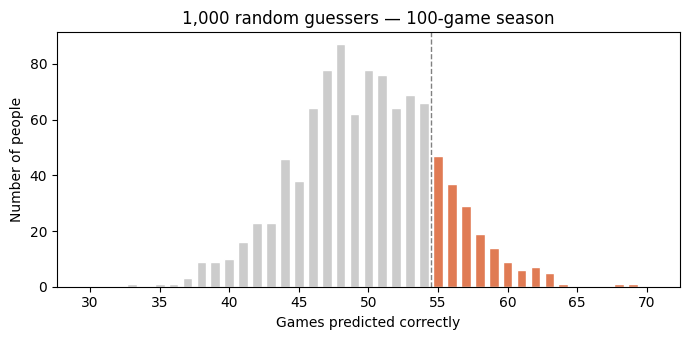

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
n, _, patches = ax.hist(random_correct_100, bins=range(30, 72), align='left',
                         rwidth=0.7, color='#cccccc', edgecolor='white')
for i, patch in enumerate(patches):
    if (i + 30) >= 55:
        patch.set_facecolor('#e07b54')
ax.axvline(54.5, ls='--', color='gray', lw=1)
ax.set(title='1,000 random guessers — 100-game season',
       xlabel='Games predicted correctly', ylabel='Number of people')
plt.tight_layout()
plt.show()

With 100 games the distribution tightens dramatically. Only around 17% of pure
coin flippers reach 55% — compared to roughly 40% over a 20-game season. It is
still not rare enough to rule out luck, but your friend's record is starting to
carry more weight. Step 4 shows exactly how many games it takes.

## 4. How many games make 55% convincing?

Simulate coin flippers across a range of season lengths. Find the point where
fewer than 10% of random guessers hit 55%+ — the threshold where skill becomes
a more likely explanation than luck.

Your friend needs to have predicted at least 170 games
for a 55% hit rate to be more likely skill than luck (< 10% chance it's random).


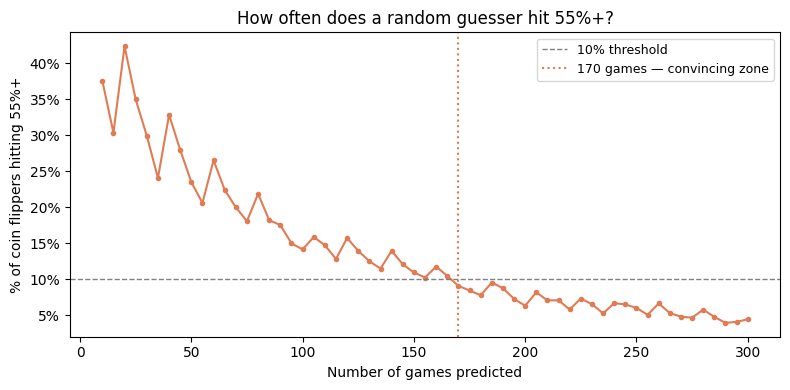

In [8]:
season_lengths = range(10, 301, 5)
chance_rates   = []

for n in season_lengths:
    flippers = RNG.binomial(n, 0.50, 5_000)
    chance_rates.append((flippers >= math.ceil(0.55 * n)).mean())

threshold = next((n for n, r in zip(season_lengths, chance_rates) if r < 0.10), None)
print(f"Your friend needs to have predicted at least {threshold} games")
print(f"for a 55% hit rate to be more likely skill than luck (< 10% chance it's random).")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(season_lengths), [r * 100 for r in chance_rates],
        '-o', ms=3, color='#e07b54')
ax.axhline(10, ls='--', color='gray', lw=1, label='10% threshold')
if threshold:
    ax.axvline(threshold, ls=':', color='#e07b54', lw=1.5,
               label=f'{threshold} games — convincing zone')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.set(title='How often does a random guesser hit 55%+?',
       xlabel='Number of games predicted', ylabel='% of coin flippers hitting 55%+')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. Takeaway

Two things went wrong with the original reasoning. First, even a genuine 55% hit
rate means you lose on roughly 45 out of every 100 games you follow — a single pick
is still close to a coin flip. Second, 55% over a 20-game season is well within what
pure chance produces. Your friend would need to have called roughly 170+ games for
their record to be more likely skill than luck.